# MAX IV support mask
Edit the circle coordinates after inspecting the amplitude overlay.

In [7]:
from pathlib import Path
import sys
import numpy as np
import matplotlib.pyplot as plt
ROOT = Path.cwd()
sys.path.insert(0, str(ROOT / 'library'))
import fth_phase_workflow as wf
import fthcore as fth
import mask_lib
DATA_H5 = ROOT / 'processed/Logs/data_recon_ImId_1143_maxiv.hdf5'
data = wf.load_data_dict(DATA_H5)
pos = np.asarray(data['holo']['+']['image_c'])
neg = np.asarray(data['holo']['-']['image_c'])
mask_pixel = np.asarray(data['mask_pixel'])
amplitude = np.abs(fth.reconstructCDI((pos + neg) * (1 - mask_pixel)))


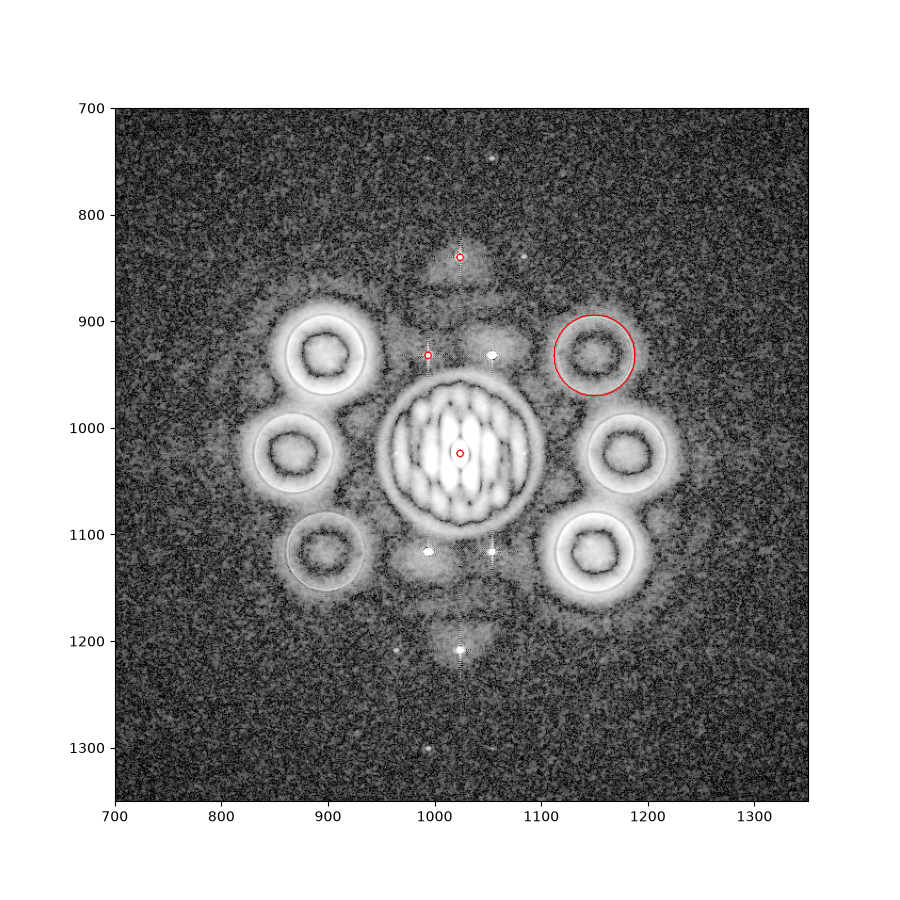

In [8]:
plt.close("all")
%matplotlib widget
# (row, column, radius); seeded from the MAX IV amplitude preview.
support_coordinates = [
    (1024, 1024, 5),
    (931, 994, 5), (932, 1150, 39),
    (840, 1024, 5)
]

support_coordinates = [
    (1024, 1024, 3),
    (932, 994, 3), (932, 1150, 38),
    (840, 1024, 3)
]



supportmask = (mask_lib.create_circle_supportmask(support_coordinates, pos.shape) > 0).astype(np.uint8)
fig, ax = plt.subplots(figsize=(9, 9))
display = np.log1p(amplitude)
ax.imshow(display, cmap='gray', vmin=np.percentile(display, 30), vmax=np.percentile(display, 99.95))
ax.contour(supportmask, levels=[0.5], colors=['red'], linewidths=0.8)
ax.set_xlim(700, 1350); ax.set_ylim(1350, 700)
plt.show()


In [9]:
data['supportmask'] = supportmask
data['support_coordinates'] = np.asarray(support_coordinates, dtype=float)
wf.save_data_dict(data, DATA_H5, overwrite=True)
print('Saved support mask:', DATA_H5, 'pixels:', int(supportmask.sum()))


Saved support mask: /home/riccardo/Desktop/Github/FTH-Phase-Retrieval-2609-SOLEIL-SEXTANTS/maxiv_phase_test/processed/Logs/data_recon_ImId_1143_maxiv.hdf5 pixels: 4600
